# Ddareungi Demand Forecasting — Weekend SARIMA/ARIMAX Pipeline

## 1. 라이브러리 로드 및 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import jarque_bera, shapiro
from sklearn.metrics import mean_squared_error, mean_absolute_error


sys.path.insert(0, str(Path('..').resolve()))

plt.rcParams['figure.dpi']   = 120
plt.rcParams['font.family']  = 'DejaVu Sans'

In [26]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

## 2. 설정값 및 데이터 로드

In [27]:
# 설정값
DATA_DIR        = Path("../data")   # interpolated_available_YYYYMM.csv
SEASONAL_PERIOD = 24             # 일일 계절 주기 (시간 단위 → S=24)
TEST_DAYS       = 30             # 마지막 30일을 test set으로 사용
TARGET_RENT_ID  = "02171"           # 분석할 정류소 ID (정수형), 가장 수요가 많길래 이거부터 진행함
ALPHA = 1.5

In [3]:
from src.config import DATA_DIR, SEASONAL_PERIOD, TEST_DAYS, LONG_MISSING
# ALPHA, TARGET_RENT_ID, 는 포함 안함. 내가 임의로 돌리기 위해
from src.utils import (
    load_filtered_csvs, make_series, 
    load_weather, load_rainfall_binary,
    adf_test, diagnose_residuals, asymmetric_rmse, evaluate_forecast,
)

df_raw = load_filtered_csvs(DATA_DIR)

# 2023~2025년만 사용
df_raw = df_raw[df_raw['datetime'].dt.year >= 2023]

print(f'Data range : {df_raw["datetime"].min().date()} ~ {df_raw["datetime"].max().date()}')
print(f'Stations   : {df_raw["RENT_ID"].nunique()}')


Data range : 2023-01-01 ~ 2025-12-31
Stations   : 23


## 3. 데이터 전처리
**결측치 처리 전략** (`missing_value_report.md` 기준)
- 단기 (1~3일): 선형 보간
- 중기 (4~14일): 동일 요일+시간대 평균 대체  
- 장기 (15일 이상): NaN 유지 → 학습 윈도우에서 제외

In [4]:
series = make_series(df_raw, TARGET_RENT_ID)
print(f"정류소 {TARGET_RENT_ID} 시계열: {len(series):,}시간")
print(f"기간: {series.index[0]} ~ {series.index[-1]}")
print(f"결측 수: {series.isna().sum()}")
series.head(10)

정류소 02171 시계열: 26,302시간
기간: 2023-01-01 01:00:00 ~ 2025-12-31 22:00:00
결측 수: 0


2023-01-01 01:00:00    1.0
2023-01-01 02:00:00    1.0
2023-01-01 03:00:00    2.0
2023-01-01 04:00:00    0.0
2023-01-01 05:00:00    1.0
2023-01-01 06:00:00    0.0
2023-01-01 07:00:00    0.0
2023-01-01 08:00:00    0.0
2023-01-01 09:00:00    0.0
2023-01-01 10:00:00    1.0
Freq: h, Name: CNT, dtype: float64

In [6]:
# 평일 / 주말 분리
series_weekday = series[series.index.dayofweek < 5]
series_weekend = series[series.index.dayofweek >= 5]

print(f"평일 데이터: {len(series_weekday):,}시간")
print(f"주말 데이터: {len(series_weekend):,}시간")

평일 데이터: 18,791시간
주말 데이터: 7,511시간


In [8]:
# Train / Test Split — 주말 데이터 기준
target_series = series_weekend.dropna()

test_hours = TEST_DAYS * 24
train = target_series.iloc[:-test_hours]
test  = target_series.iloc[-test_hours:]

print(f"Train: {train.index[0]} ~ {train.index[-1]} ({len(train):,}시간)")
print(f"Test : {test.index[0]} ~ {test.index[-1]} ({len(test):,}시간)")

Train: 2023-01-01 01:00:00 ~ 2025-09-14 23:00:00 (6,791시간)
Test : 2025-09-20 00:00:00 ~ 2025-12-28 23:00:00 (720시간)


## 4. 정상성 검정 — ADF Test
- $H_0$: 단위근 존재 (non-stationary)  
- $H_1$: 단위근 없음 (stationary)  
- p-value < 0.05이면 정상성 확보


In [9]:
print("=" * 50)
is_stationary = adf_test(train, name=f"Station {TARGET_RENT_ID} (raw)")

if not is_stationary:
    print(f"\nS={SEASONAL_PERIOD} 계절 차분 후 재검정...")
    train_diff = train.diff(SEASONAL_PERIOD).dropna()
    print("=" * 50)
    adf_test(train_diff, name=f"Station {TARGET_RENT_ID} (after seasonal diff)")
else:
    train_diff = train

[ADF Test] Station 02171 (raw)
  ADF Statistic : -25.2180
  p-value       : 0.0000
  Critical (1%) : -3.4313
  Critical (5%) : -2.8620
  결론          : 정상 (stationary)


## 5. ACF / PACF 시각화
차수 후보 파악: ACF → MA 차수, PACF → AR 차수


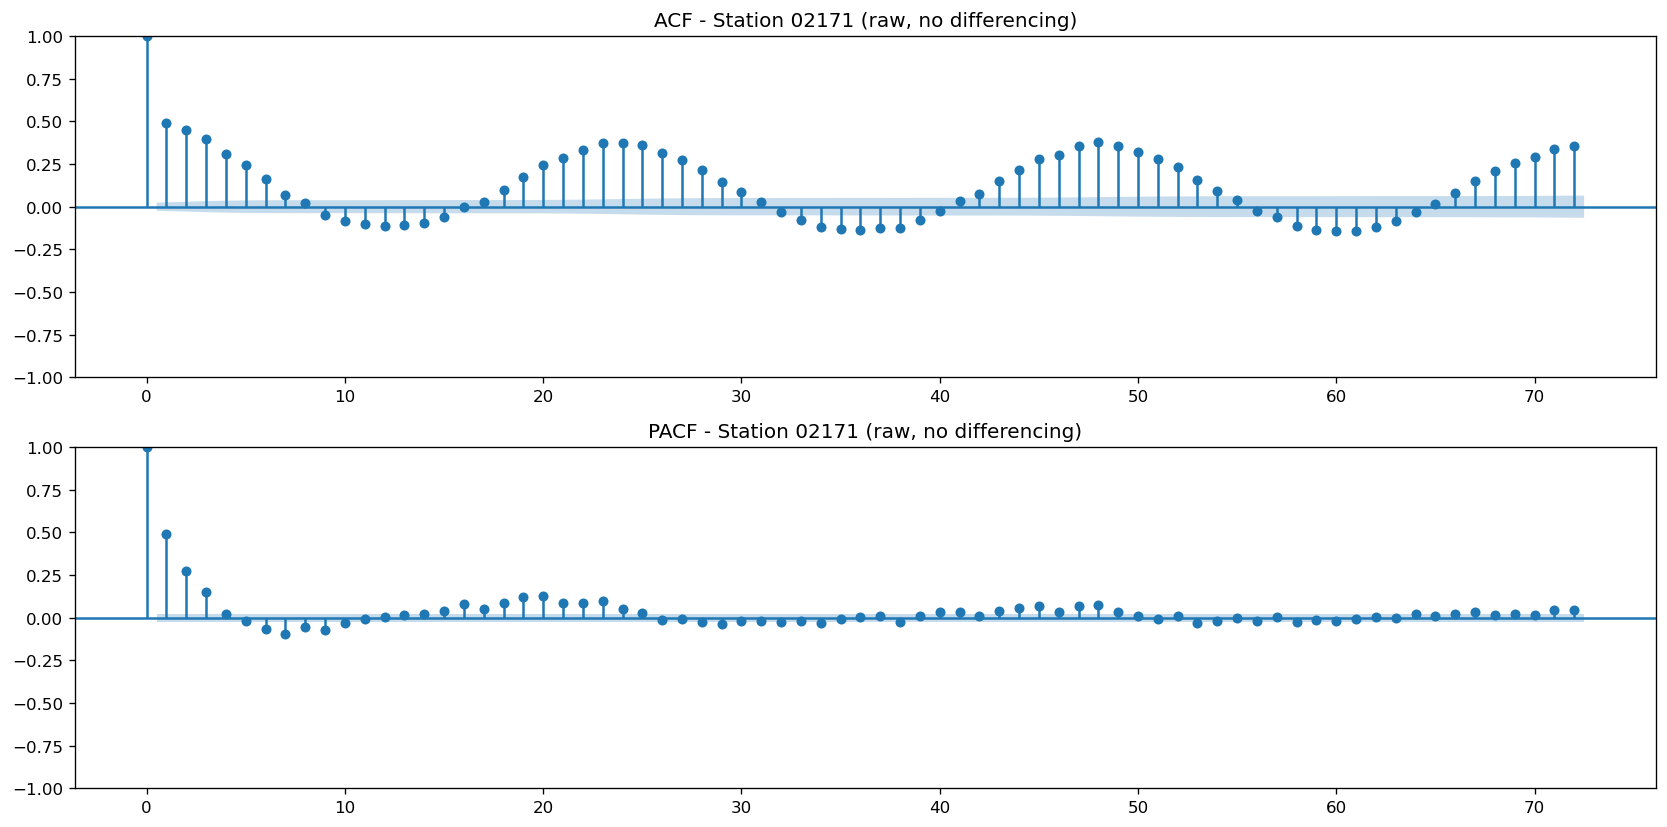

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_diff.dropna(), lags=72, ax=axes[0],
         title=f"ACF - Station {TARGET_RENT_ID} (raw, no differencing)")
plot_pacf(train_diff.dropna(), lags=72, ax=axes[1],
          title=f"PACF - Station {TARGET_RENT_ID} (raw, no differencing)")
plt.tight_layout()
plt.show()

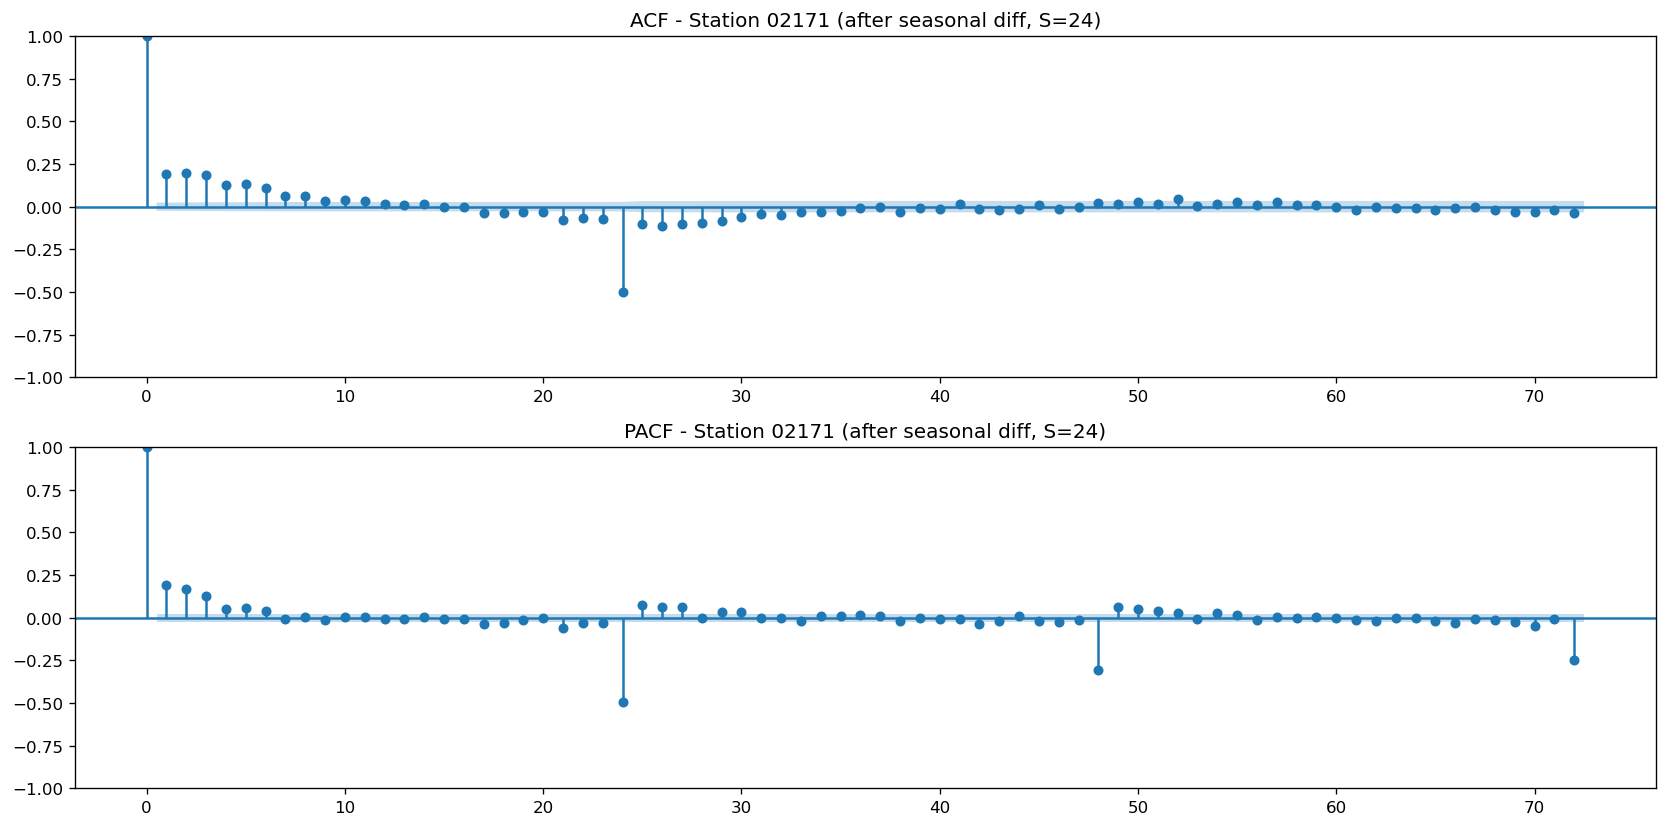

In [11]:
# ADF는 정상으로 판정했으나 계절성이 남아있으므로
# 계절 차분(D=1, S=24) 후 ACF/PACF로 차수 후보 파악
train_diff_seasonal = train.diff(SEASONAL_PERIOD).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_diff_seasonal,  lags=72, ax=axes[0],
         title=f"ACF - Station {TARGET_RENT_ID} (after seasonal diff, S=24)")
plot_pacf(train_diff_seasonal, lags=72, ax=axes[1],
          title=f"PACF - Station {TARGET_RENT_ID} (after seasonal diff, S=24)")
plt.tight_layout()
plt.show()

## 6. SARIMA 모델 적합
`auto_arima`로 AIC 기준 최적 차수 자동 선택
계절 주기 **S=24** (시간 단위 데이터 → 하루 주기)


In [13]:
# 차수 탐색
%run ../scripts/sarima_auto_arima_weekend.py

# 탐색 결과 자동으로 받아서 적합
order          = BEST_ORDER
seasonal_order = BEST_SEASONAL_ORDER
print(f"Using order: ARIMA{order}x{seasonal_order}")

sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Data range : 2023-01-01 ~ 2025-12-31
Weekend train : 2023-01-01 ~ 2025-12-28  (7,511 hours)

Running statsforecast AutoARIMA...

ARIMA(2,0,2)(1,1,1)[24] with drift        :inf

ARIMA(0,0,0)(0,1,0)[24] with drift        :25046.172954606984

ARIMA(1,0,0)(1,1,0)[24] with drift        :22730.978075448278

ARIMA(0,0,1)(0,1,1)[24] with drift        :inf

ARIMA(0,0,0)(0,1,0)[24]                   :25058.52159101679

ARIMA(1,0,0)(0,1,0)[24] with drift        :24998.204471124678

ARIMA(1,0,0)(2,1,0)[24] with drift        :22088.965631802515

ARIMA(1,0,0)(2,1,1)[24] with drift        :inf

ARIMA(1,0,0)(1,1,1)[24] with drift        :inf

ARIMA(0,0,0)(2,1,0)[24] with drift        :22114.159862337685

ARIMA(2,0,0)(2,1,0)[24] with drift        :22000.723669001698

ARIMA(2,0,0)(1,1,0)[24] with drift        :22676.510212420915

ARIMA(2,0,0)(2,1,1)[24] with drift        :inf

ARIMA(2,0,0)(1,1,1)[24] with drift        :inf

ARIMA(2,0,1)(2,1,0)[24] with drift        :21986.205813139226

ARIMA(2,0,1)(1,1,

NameError: name 'BEST_ORDER' is not defined

In [14]:
# 탐색 결과 자동으로 받아서 적합
order          = (1, 0, 2)
seasonal_order = (2, 1, 0, 24)
print(f"Using order: ARIMA{order}x{seasonal_order}")

sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Using order: ARIMA(1, 0, 2)x(2, 1, 0, 24)
                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                 6791
Model:             SARIMAX(1, 0, 2)x(2, 1, [], 24)   Log Likelihood              -13769.796
Date:                             Wed, 27 May 2026   AIC                          27551.591
Time:                                     03:25:39   BIC                          27592.466
Sample:                                          0   HQIC                         27565.705
                                            - 6791                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8347      0.018     47.442      0.000       0.8

## 7. ARIMAX 모델 적합
기상 데이터(기온, 강수량)를 외생변수로 추가  
기상청 데이터 수집 후 `weather.csv`로 저장하여 사용


In [15]:
# load_rainfall_binary: 기온 + rain_binary(1mm 기준) 반환
# 동절기(11~3월) 결측 → 앞뒤 3시간 이내 관측값이 둘 다 1일 때만 1, 나머지 0
# 하절기(4~10월) 결측 → 0 (보수적 처리)
weather_df = load_rainfall_binary(DATA_DIR, threshold=1.0)

exog_train = weather_df.loc[weather_df.index.isin(train.index)][['temp', 'rain_binary']]
exog_test  = weather_df.loc[weather_df.index.isin(test.index)][['temp', 'rain_binary']]

print(f'Exog train shape: {exog_train.shape}')
print(f'Missing in exog_train: {exog_train.isna().sum().to_dict()}')
exog_train.head()

Exog train shape: (6791, 2)
Missing in exog_train: {'temp': 0, 'rain_binary': 0}


,temp,rain_binary
datetime,,
2023-01-01 01:00:00,1.5,0
2023-01-01 02:00:00,1.5,0
2023-01-01 03:00:00,1.6,0
2023-01-01 04:00:00,1.5,0
2023-01-01 05:00:00,0.8,0


In [16]:
# ARIMAX 적합

arimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_fit = arimax_model.fit(disp=False)
print(arimax_fit.summary())


                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                 6791
Model:             SARIMAX(1, 0, 2)x(2, 1, [], 24)   Log Likelihood              -13666.850
Date:                             Wed, 27 May 2026   AIC                          27349.699
Time:                                     03:26:49   BIC                          27404.199
Sample:                                          0   HQIC                         27368.518
                                            - 6791                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temp            0.0916      0.009     10.561      0.000       0.075       0.109
rain_binary    -1.1447  

In [17]:
# ARIMAX (강수여부만 외생변수)
exog_train_rain = exog_train[['rain_binary']]
exog_test_rain  = exog_test[['rain_binary']]

arimax_rain_model = SARIMAX(
    train,
    exog=exog_train_rain,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_rain_fit = arimax_rain_model.fit(disp=False)
print(arimax_rain_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                 CNT   No. Observations:                 6791
Model:             SARIMAX(1, 0, 2)x(2, 1, [], 24)   Log Likelihood              -13724.049
Date:                             Wed, 27 May 2026   AIC                          27462.099
Time:                                     03:28:30   BIC                          27509.787
Sample:                                          0   HQIC                         27478.565
                                            - 6791                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
rain_binary    -1.1973      0.136     -8.815      0.000      -1.463      -0.931
ar.L1           0.8248  

## 8. 잔차 진단
| 검정 | 귀무가설 |
|------|----------|
| Ljung-Box | 잔차에 자기상관 없음 (백색잡음) |
| Jarque-Bera | 잔차가 정규분포를 따름 |
| Shapiro-Wilk | 잔차가 정규분포를 따름 |


  잔차 진단: SARIMA

[Ljung-Box Test] H0: 잔차에 자기상관 없음
       lb_stat     lb_pvalue
10   16.715394  8.090363e-02
20   34.341278  2.390667e-02
48  317.765144  1.895903e-41
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=1952.4451, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9613, p-value=0.0000
  → 정규성 기각


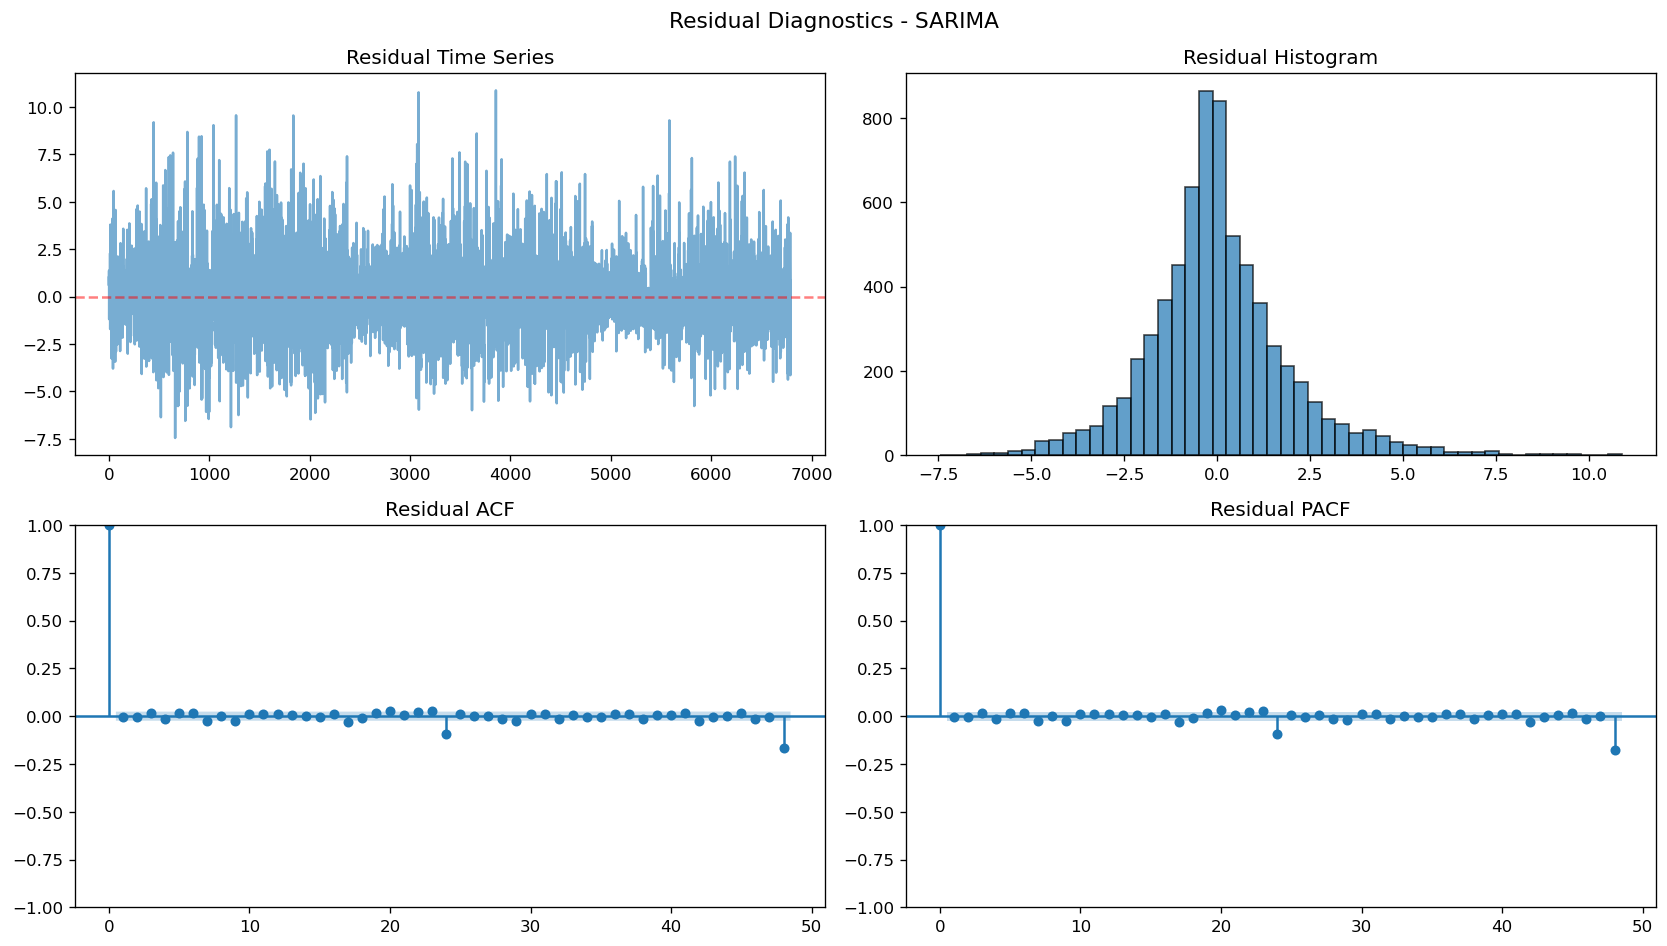

In [18]:
# SARIMA 잔차 진단
diag_sarima = diagnose_residuals(sarima_fit, model_name="SARIMA")

  잔차 진단: ARIMAX

[Ljung-Box Test] H0: 잔차에 자기상관 없음
      lb_stat     lb_pvalue
10   17.12697  7.160124e-02
20   34.69820  2.177182e-02
48  321.09961  4.542209e-42
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=1901.1519, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9635, p-value=0.0000
  → 정규성 기각


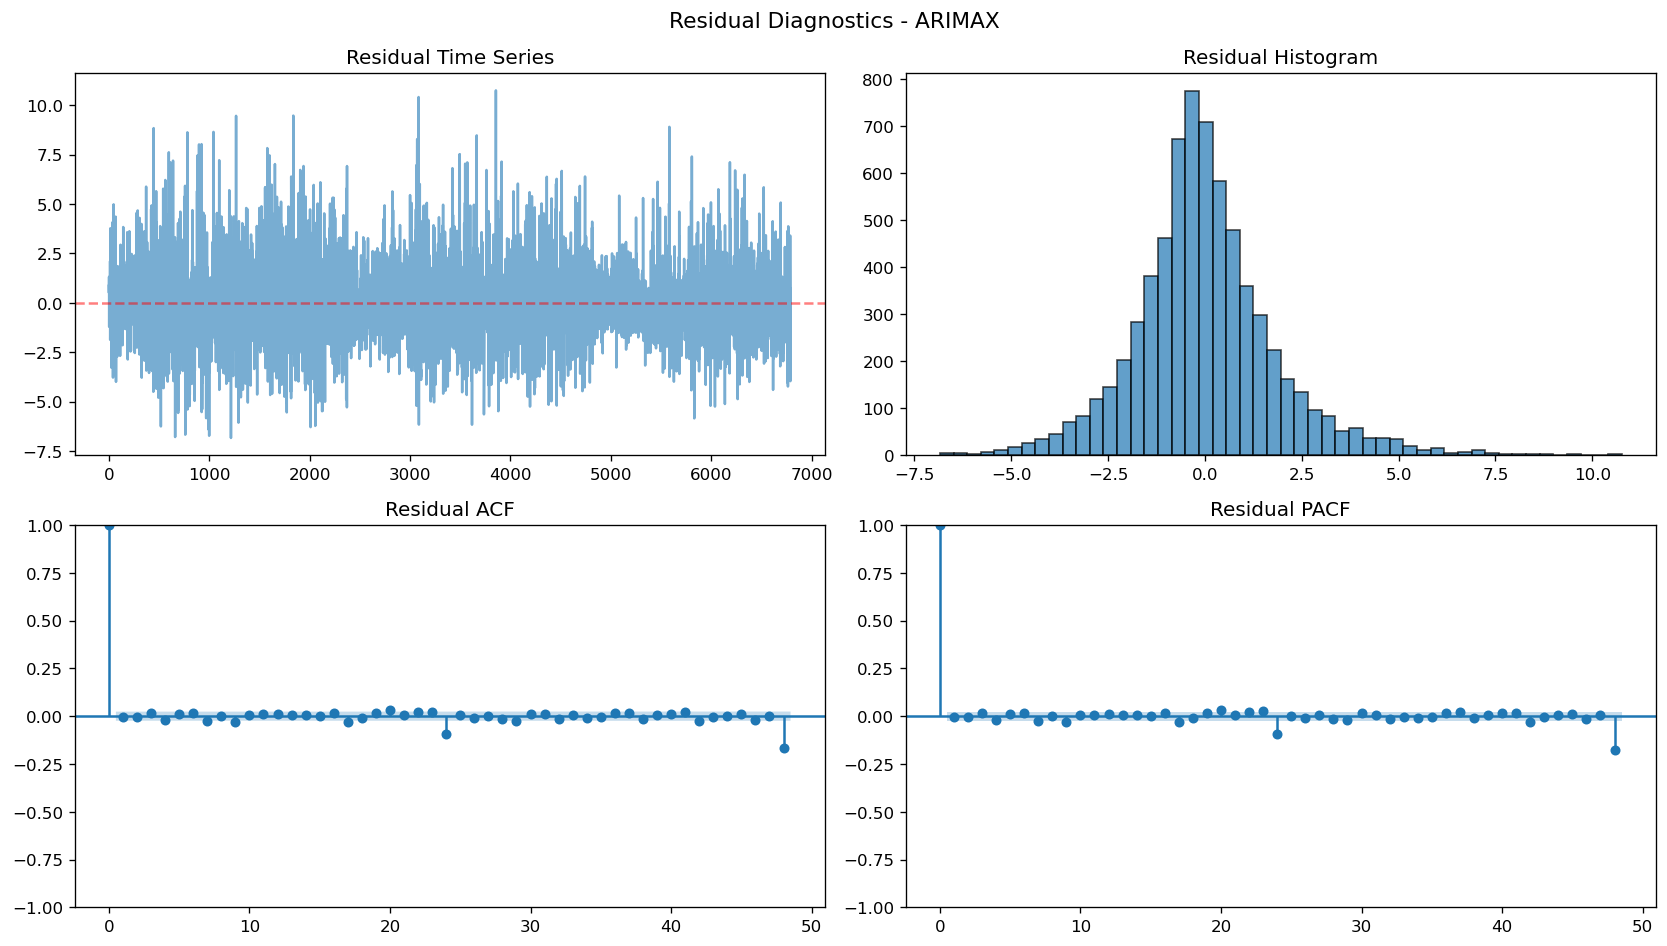

In [19]:
# ARIMAX 잔차 진단
diag_arimax = diagnose_residuals(arimax_fit, model_name="ARIMAX")

  잔차 진단: ARIMAX

[Ljung-Box Test] H0: 잔차에 자기상관 없음
       lb_stat     lb_pvalue
10   16.041683  9.844536e-02
20   33.606126  2.891587e-02
48  317.716918  1.935456e-41
  → 자기상관 존재

[Jarque-Bera Test] H0: 정규분포
  통계량=2048.4429, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9608, p-value=0.0000
  → 정규성 기각


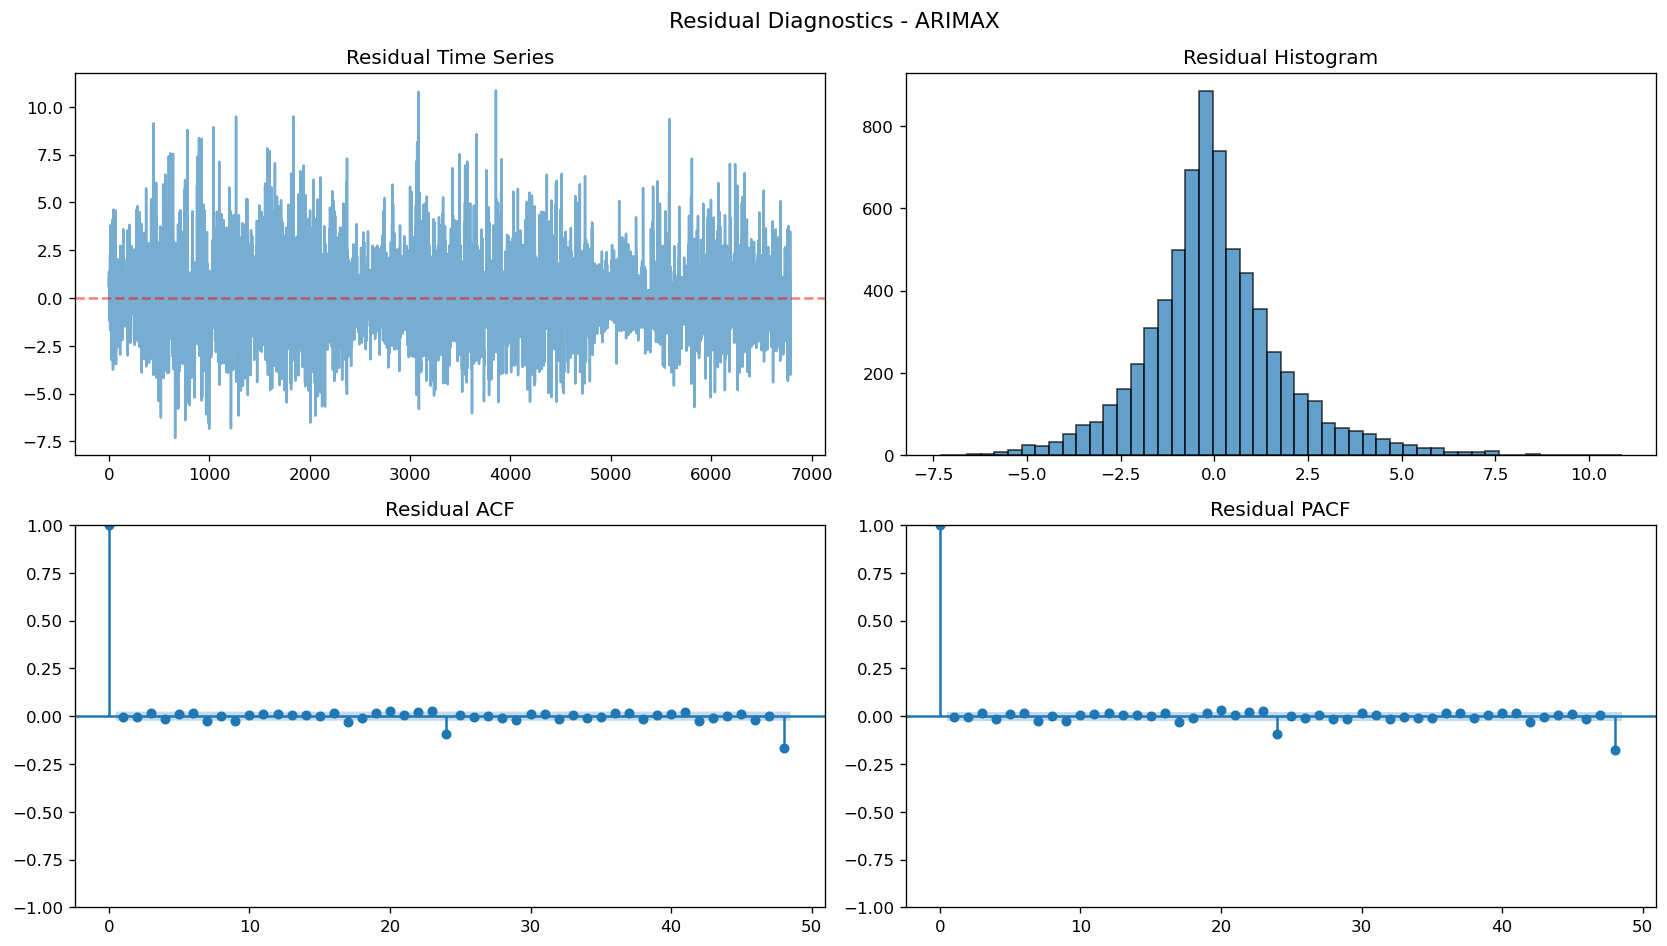

In [21]:
# ARIMAX 잔차 진단 (강수량만)
diag_arimax_rain = diagnose_residuals(arimax_rain_fit, model_name="ARIMAX")

## 9. 예측 성능 평가

### 평가 지표
| 지표 | 설명 | 비고 |
|------|------|------|
| **RMSE** | 기본 예측 정확도, 큰 오차에 민감 | 주요 지표 |
| **MAE** | 평균 절대 오차, 이상치 영향 적음 | 보조 지표 |
| **Asymmetric RMSE** | 과소예측에 $\alpha$배 패널티 | 조교님 권장 |
| **과소예측 비율** | $\hat{y} < y$ 인 비율 | 자전거 고갈 위험도 |

### 비대칭 손실함수
$$L(\hat{y}, y) = \begin{cases} \alpha \cdot (\hat{y} - y)^2 & \text{if } \hat{y} < y \text{ (과소예측)} \\ (\hat{y} - y)^2 & \text{if } \hat{y} \geq y \text{ (과대예측)} \end{cases}$$

- $y$: 실제 대여 건수 (CNT)
- $\hat{y}$: 모델이 예측한 대여 건수
- $\alpha > 1$: 과소예측 패널티 가중치 (기본값 $\alpha=2$)


[SARIMA]
  RMSE              : 1.582
  MAE               : 1.179
  Asymmetric RMSE   : 1.722  (alpha=1.5)
  과소예측 비율      : 34.3%


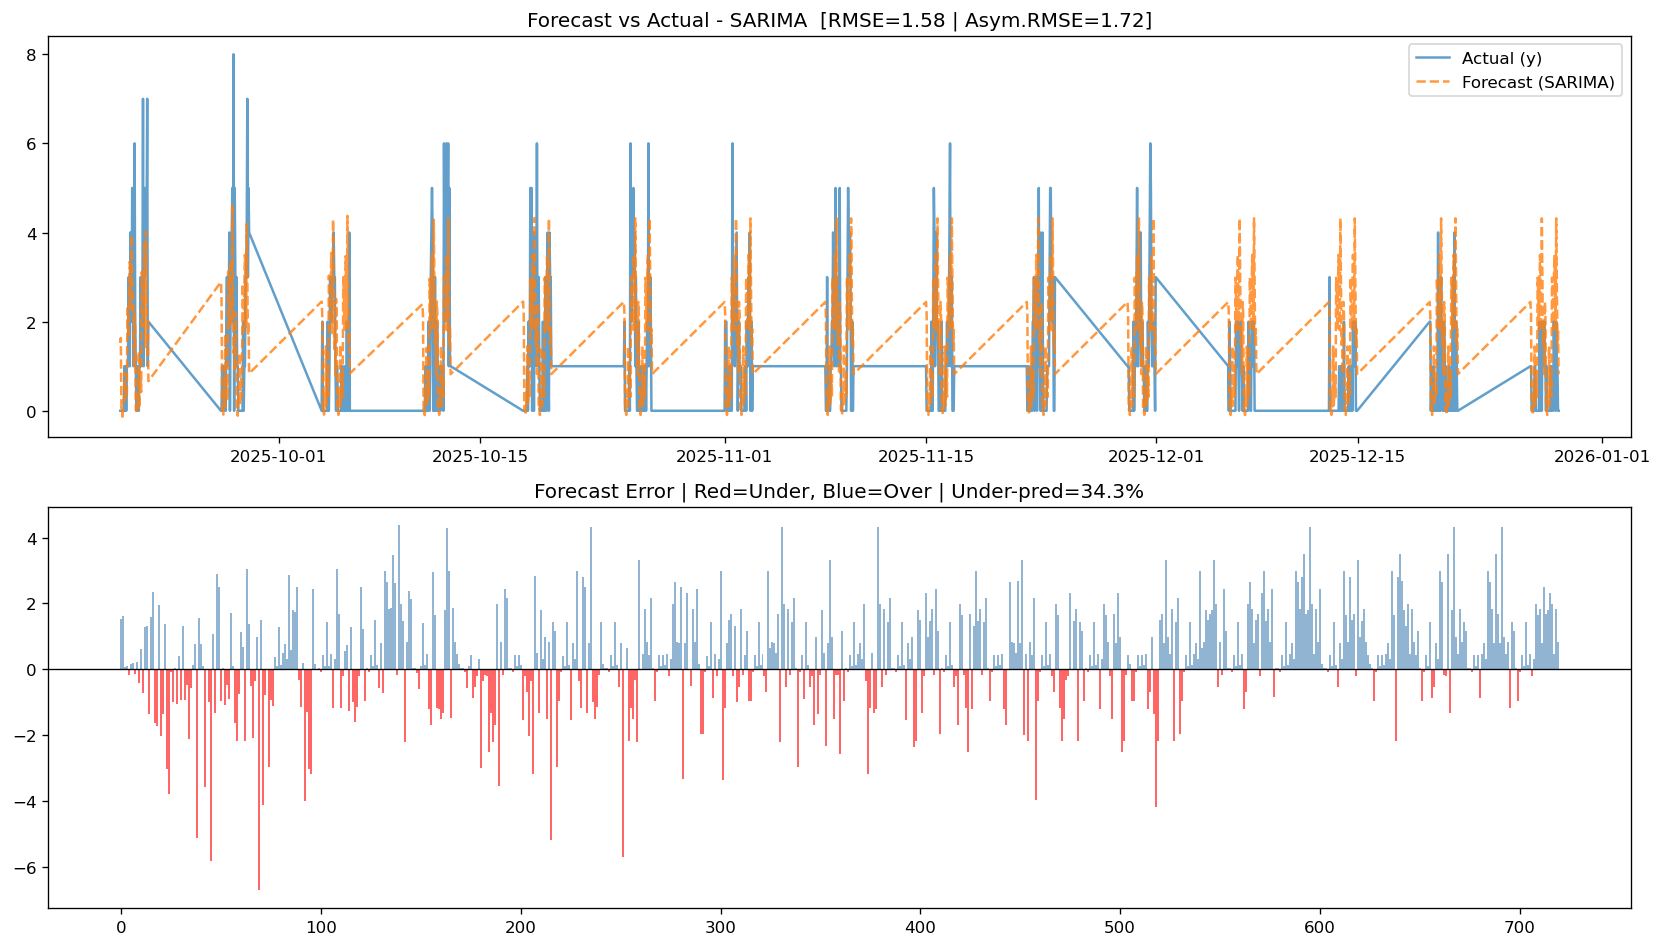

In [30]:
perf_sarima = evaluate_forecast(sarima_fit, test, model_name="SARIMA", alpha=ALPHA)

[ARIMAX]
  RMSE              : 1.664
  MAE               : 1.311
  Asymmetric RMSE   : 1.982  (alpha=1.5)
  과소예측 비율      : 70.7%


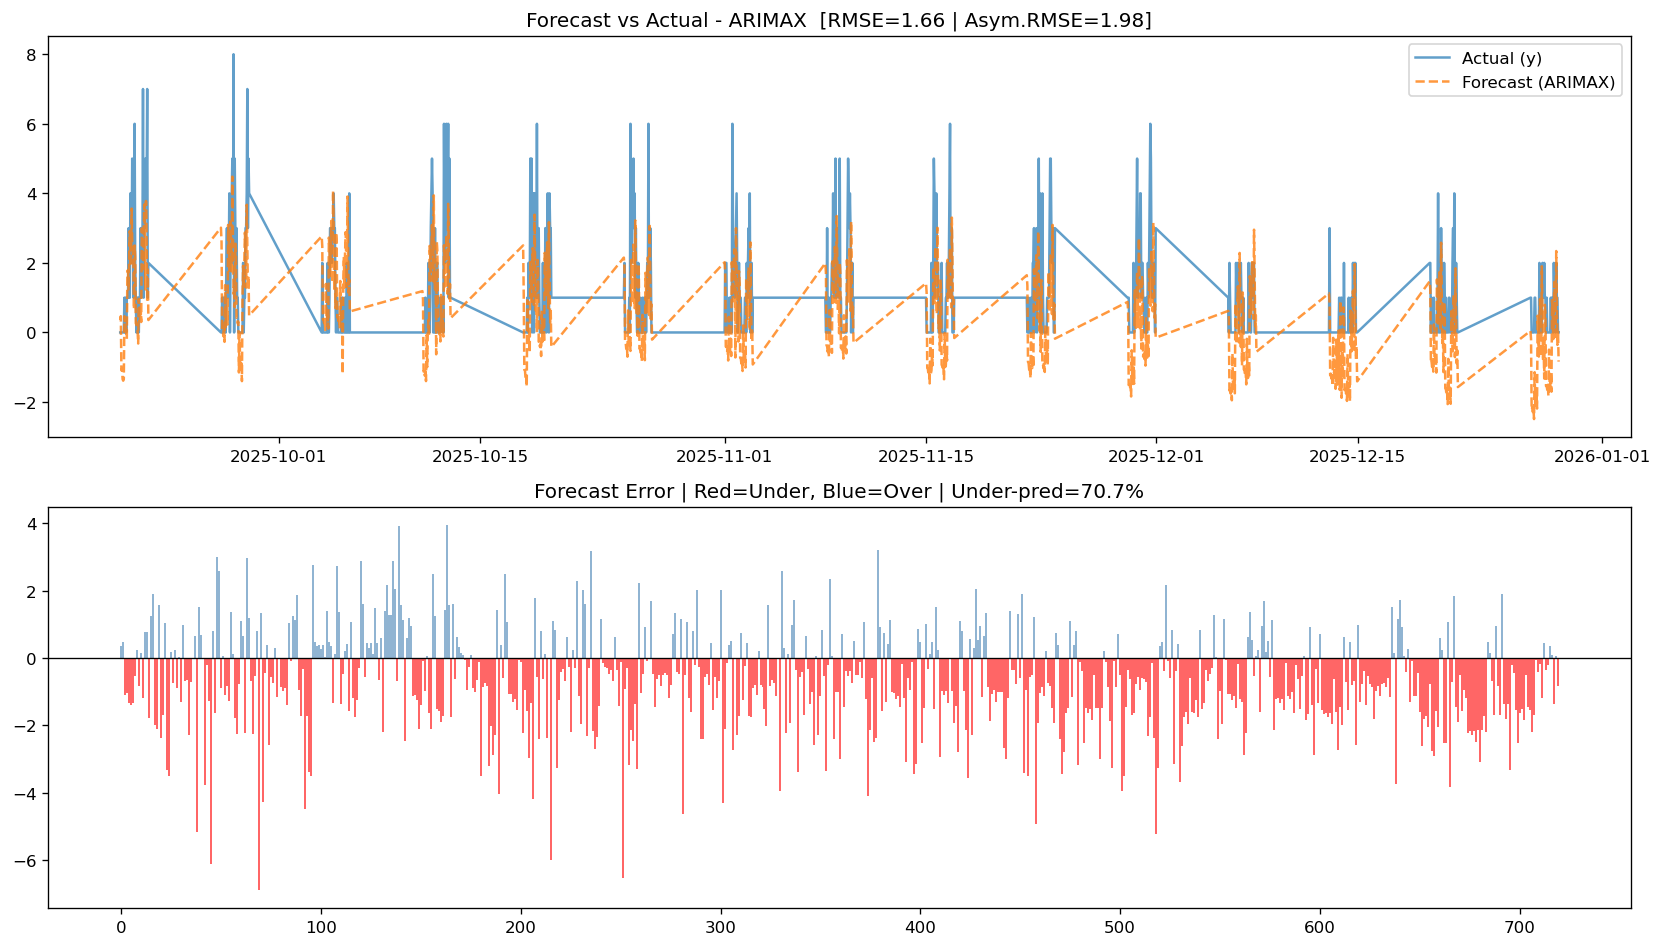

In [29]:
perf_arimax = evaluate_forecast(arimax_fit, test, model_name="ARIMAX",
                                exog_test=exog_test, alpha=ALPHA)

[ARIMAX (rain only)]
  RMSE              : 1.575
  MAE               : 1.218
  Asymmetric RMSE   : 1.712  (alpha=1.5)
  과소예측 비율      : 33.5%


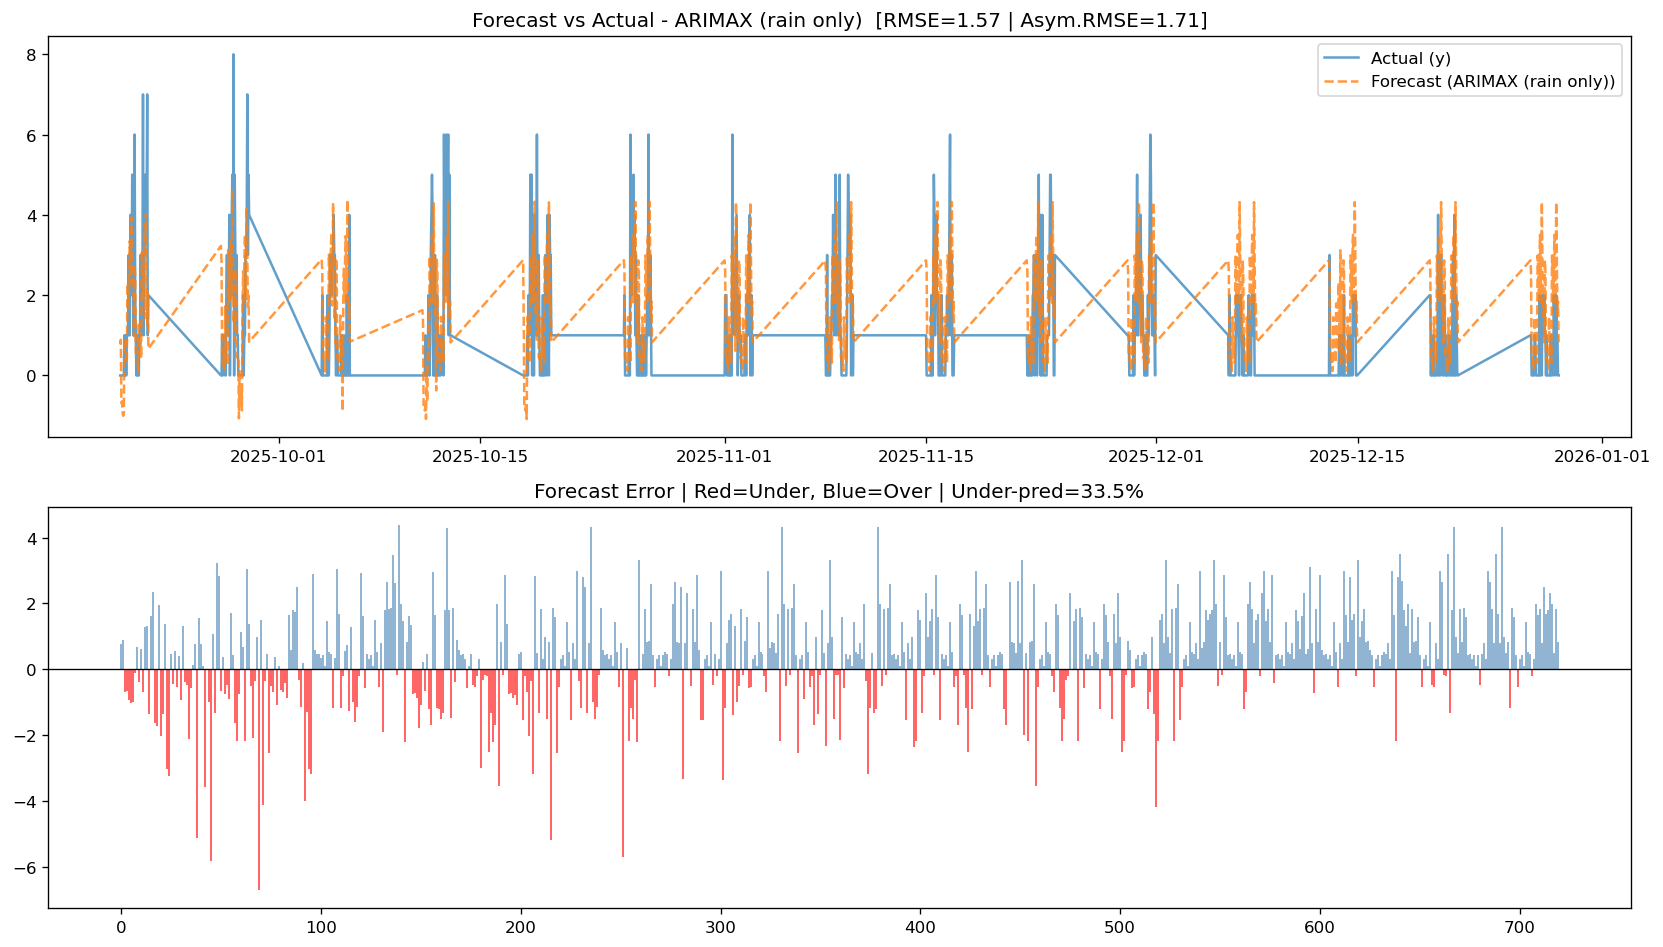

In [28]:
perf_arimax_rain = evaluate_forecast(arimax_rain_fit, test, model_name='ARIMAX (rain only)',
                                     exog_test=exog_test_rain, alpha=ALPHA)

## 10. 모델 성능 비교


         Model Performance Comparison
                     RMSE    MAE  Asym.RMSE(α=1.5)  과소예측비율(%)
model                                                        
SARIMA              1.582  1.179             1.722       34.3
ARIMAX              1.664  1.311             1.982       70.7
ARIMAX (rain only)  1.575  1.218             1.712       33.5


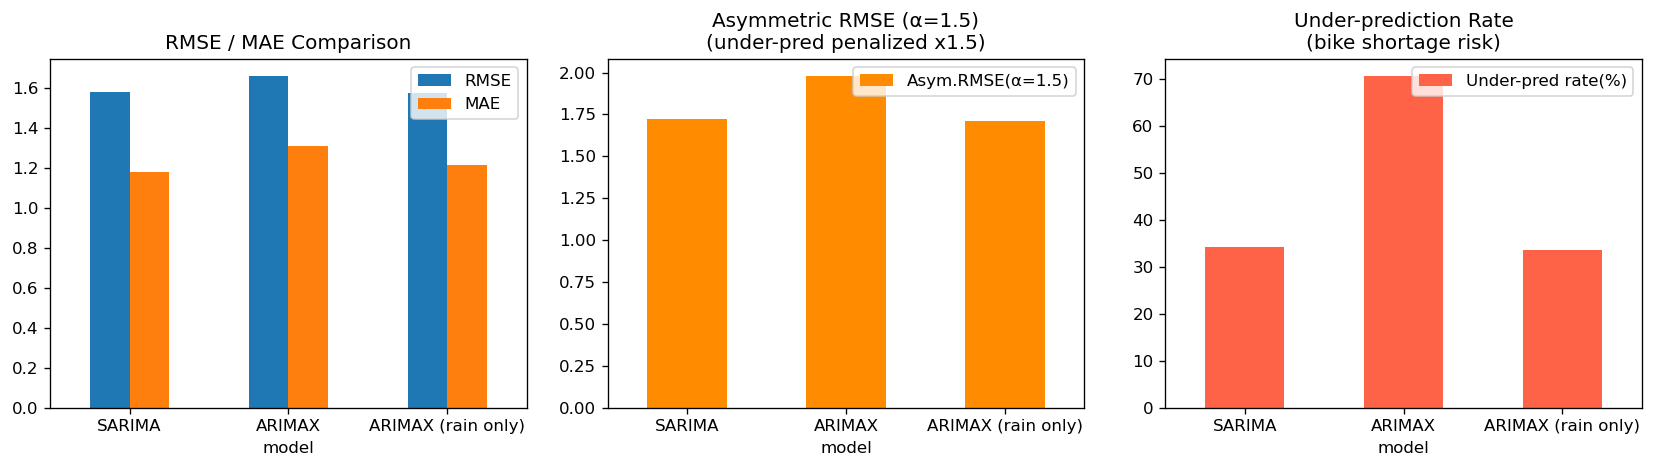

In [31]:
result_df = pd.DataFrame([perf_sarima, perf_arimax, perf_arimax_rain]).set_index("model")
print("\n" + "="*55)
print("         Model Performance Comparison")
print("="*55)
print(result_df.to_string())

# Visualization
asym_col = f"Asym.RMSE(α={ALPHA})"
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

result_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0],
    title="RMSE / MAE Comparison", rot=0)

result_df[[asym_col]].plot(kind="bar", ax=axes[1],
    title=f"Asymmetric RMSE (α={ALPHA})\n(under-pred penalized x{ALPHA})", rot=0, color="darkorange")

result_df[["과소예측비율(%)"]].rename(
    columns={"과소예측비율(%)": "Under-pred rate(%)"}
).plot(kind="bar", ax=axes[2],
    title="Under-prediction Rate\n(bike shortage risk)", rot=0, color="tomato")

plt.tight_layout()
plt.show()